In [1]:
# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [2]:
# %%
DATASET_PATH = "Weather-Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

val_size = int(len(dataset) * VAL_SPLIT)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

print("Classes:", dataset.classes)
print("Train size:", train_size)
print("Val size:", val_size)

Classes: ['cloudy', 'foggy', 'rainy', 'snowy', 'sunny']
Train size: 14431
Val size: 3607


In [3]:
# %%
model = models.densenet121(weights="IMAGENET1K_V1")

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 5)

model = model.to(device)

print("DenseNet121 loaded successfully")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:03<00:00, 8.62MB/s]


DenseNet121 loaded successfully


In [6]:
# %%
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

scaler = torch.cuda.amp.GradScaler()

print("Training setup ready")

Training setup ready


C:\Users\DELL\AppData\Local\Temp\ipykernel_5380\1808873951.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [8]:
# %%
EPOCHS = 15
best_val_acc = 0

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()
    train_correct = 0
    train_total = 0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # ===== Validation =====
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_densenet_model.pth")
        print("Best model saved")

total_time = (time.time() - start_time) / 60

print("\nTraining completed")
print(f"Best Accuracy: {best_val_acc:.2f}%")
print(f"Total Time: {total_time:.2f} minutes")


Epoch 1/15


  0%|          | 0/451 [00:00<?, ?it/s]C:\Users\DELL\AppData\Local\Temp\ipykernel_5380\536191669.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 451/451 [07:30<00:00,  1.00it/s]


Train Accuracy: 82.96%
Validation Accuracy: 87.11%
Best model saved

Epoch 2/15


100%|██████████| 451/451 [02:54<00:00,  2.58it/s]


Train Accuracy: 87.75%
Validation Accuracy: 88.22%
Best model saved

Epoch 3/15


...

Train Accuracy: 97.55%
Validation Accuracy: 91.77%

Epoch 14/15


100%|██████████| 451/451 [02:35<00:00,  2.90it/s]


Train Accuracy: 97.79%
Validation Accuracy: 91.63%

Epoch 15/15


100%|██████████| 451/451 [02:24<00:00,  3.12it/s]


Train Accuracy: 97.82%
Validation Accuracy: 91.88%

Training completed
Best Accuracy: 92.10%
Total Time: 49.44 minutes


C:\Users\DELL\AppData\Local\Temp\ipykernel_5380\2934605400.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_densenet_model.pth"))



Classification Report:

              precision    recall  f1-score   support

      cloudy       0.91      0.91      0.91      1303
       foggy       0.92      0.91      0.91       268
       rainy       0.89      0.90      0.89       368
       snowy       0.94      0.92      0.93       381
       sunny       0.93      0.93      0.93      1287

    accuracy                           0.92      3607
   macro avg       0.92      0.91      0.91      3607
weighted avg       0.92      0.92      0.92      3607



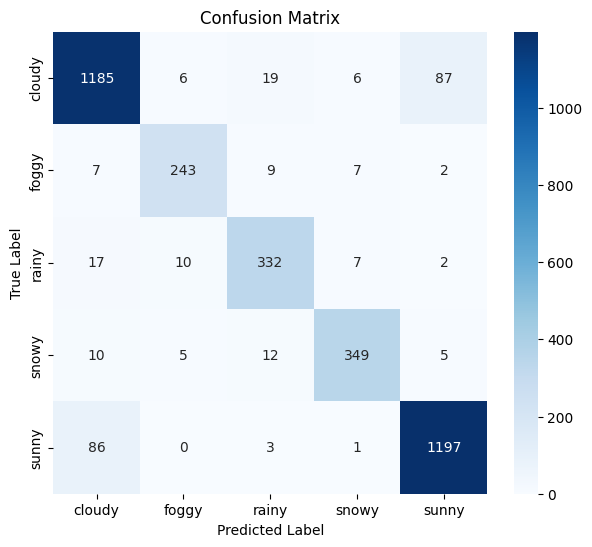

In [9]:
# %%
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_densenet_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = dataset.classes

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()